In [28]:

# Name: Adeel Ashfaque
# section: G
# cms: 023-24-228
# https://github.com/AdeelAshfaque
# https://www.kaggle.com/adeelashfaque

In [ ]:
# part 1

In [29]:
import pandas as pd

df = pd.read_csv("clean_churn.csv")

print(df.shape)
print(df.info())
print(df.head)


(7043, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null

In [30]:
# In Lab 3, the Decision Tree achieved a test-set accuracy of 0.7984, precision of 0.6347, recall of 0.5668, and F1 score of 0.5989.
# In Lab 4, the tuned Random Forest performed better, achieving an accuracy of 0.8730, precision of 0.8037, recall of 0.6898, and F1
# score of 0.7424. These results will be used as benchmarks to evaluate the Logistic Regression and KNN models in this lab.


In [31]:
# part 2 

In [32]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])
X = df.drop('Churn', axis=1)
Y = df['Churn'].map({'No': 0, 'Yes':1})

X = pd.get_dummies(X, drop_first=True)

print('X shape: ', X.shape)
print('Y shape: ', Y.shape)
print(Y.value_counts)

X shape:  (7043, 30)
Y shape:  (7043,)
<bound method IndexOpsMixin.value_counts of 0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64>


In [33]:
# Feature scaling is important in KNN because it needs to calcualte the distance and if we will not freature extract then the larger 
# distances would dominate and our results will not be optimal.
# Logistic regression tries to make a perfect slope. If we will not do the feature extraction then the large values will affect the 
# perfect slope and the reults will not be optimal.
# On the other hand the classification models like random forest and decision tree makes decision on certain threshold which does not 
# affect them.

In [34]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X,Y,random_state=42, stratify=Y)

print(x_train.shape)
print(y_train.shape)

(5282, 30)
(5282,)


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Scaled training set: ", x_train_scaled.shape)
print("Scaled testing set: ", x_test_scaled.shape)

Scaled training set:  (5282, 30)
Scaled testing set:  (1761, 30)


In [36]:
# we need to fit scaler on training features only because the testing features or in other words y only contain one feature that is result
# which has only two values 1 or 0. so there is no need of fitting scaler.

In [37]:
# part 3

In [38]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(x_train_scaled, y_train)

y_pred = model.predict(x_test_scaled)


In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

logreg_accuracy = accuracy_score(y_test, y_pred)
logreg_precision = precision_score(y_test, y_pred)
logreg_recall = recall_score(y_test, y_pred)
logreg_f1 = f1_score(y_test, y_pred)

print("accuracy: ", logreg_accuracy)
print("precision: ", logreg_precision)
print("recall: ", logreg_recall)
print("f1: ", logreg_f1)

accuracy:  0.8069278818852924
precision:  0.6615776081424937
recall:  0.556745182012848
f1:  0.6046511627906976


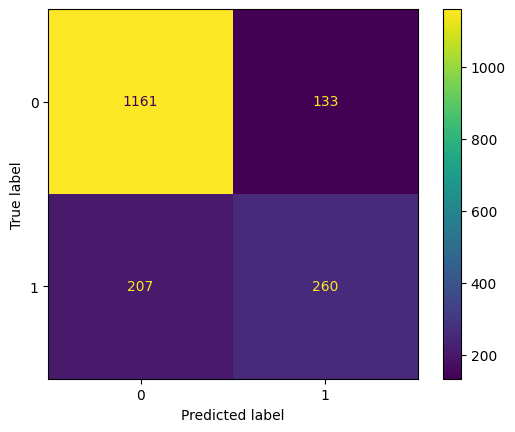

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [41]:
probabilities = model.predict_proba(x_test_scaled[:5])
print(probabilities)

[[0.83423857 0.16576143]
 [0.94795438 0.05204562]
 [0.94692163 0.05307837]
 [0.28404007 0.71595993]
 [0.98310783 0.01689217]]


In [42]:
# The predict proba method gives the probability of each class. The first row represents the no churn and second one represents probability
# of churn.

In [43]:
# part 4

In [44]:
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

k_values = [1, 3, 5, 7, 9, 11, 15, 21]

results=[]

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train_scaled, y_train)

    y_pred_knn = knn.predict(x_test_scaled)

    accuracy = accuracy_score(y_test, y_pred_knn)
    f1 = f1_score(y_test, y_pred_knn)

    results.append({
        "K": k,
        "Accuracy": accuracy,
        "F1-score": f1
    })

results_df = pd.DataFrame(results)
print(results_df)



    K  Accuracy  F1-score
0   1  0.715503  0.466454
1   3  0.744463  0.521277
2   5  0.752413  0.525054
3   7  0.771153  0.561480
4   9  0.775128  0.571429
5  11  0.777967  0.574538
6  15  0.773424  0.564885
7  21  0.777399  0.573913


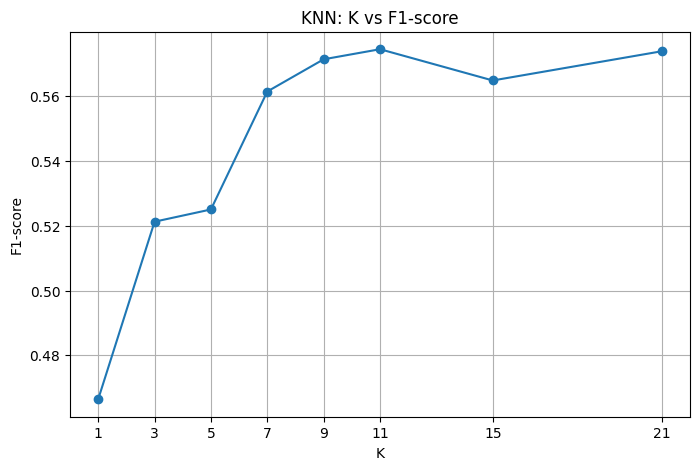

In [45]:
plt.figure(figsize=(8,5))
plt.plot(results_df["K"],results_df["F1-score"], marker="o")
plt.xlabel("K")
plt.ylabel("F1-score")
plt.title("KNN: K vs F1-score")
plt.xticks(k_values)
plt.grid(True)
plt.show()


In [46]:
# based on the results i would choose k=11 because it gives the highest f1 score and highiest accuracy.
# I would not choose small k because it would overfit the data. and the higher k would underfit it .


In [47]:
final_knn = KNeighborsClassifier(n_neighbors=11)

final_knn.fit(x_train_scaled, y_train)

y_pred_final = final_knn.predict(x_test_scaled)

In [48]:
knn_accuracy = accuracy_score(y_test, y_pred_final)
knn_precision = precision_score(y_test, y_pred_final)
knn_recall = recall_score(y_test, y_pred_final)
knn_f1 = f1_score(y_test, y_pred_final)

print("Accuracy:", knn_accuracy)
print("Precision:", knn_precision)
print("Recall:", knn_recall)
print("F1-score:", knn_f1)

Accuracy: 0.7779670641680864
Precision: 0.584070796460177
Recall: 0.5653104925053534
F1-score: 0.5745375408052231


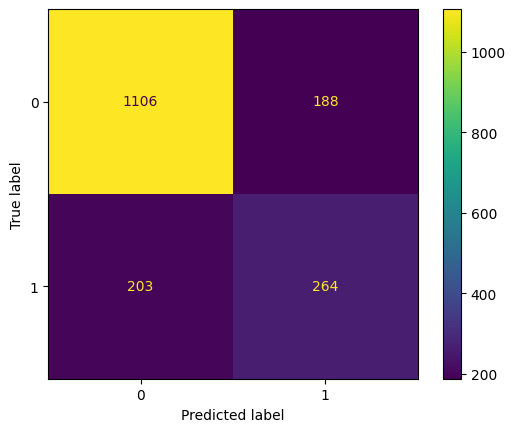

In [49]:
cm = confusion_matrix(y_test, y_pred_final)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

In [50]:
# part 5

In [51]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Logistic Regression",
        "KNN"
    ],
    "Accuracy": [
        0.7984,
        0.8730,
        logreg_accuracy,
        knn_accuracy
    ],
    "Precision": [
        0.6347,
        0.8037,
        logreg_precision,
        knn_precision
    ],
    "Recall": [
        0.5668,
        0.6898,
        logreg_recall,
        knn_recall
    ],
    "F1-Score": [
        0.5989,
        0.7424,
        logreg_f1,
        knn_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.798400,0.634700,0.566800,0.598900
1,Random Forest,0.873000,0.803700,0.689800,0.742400
2,Logistic Regression,0.806928,0.661578,0.556745,0.604651
3,KNN,0.777967,0.584071,0.565310,0.574538


In [ ]:
# Logistic regression performed best overall. The ranking does not change when switching between these metrics because random forest has
# the highest value.Recall is especially important for this churn problem because we want to identify as many customers as possible
# who will actually  churn. A higher recall means fewer actual churn customers are missed by the model.

In [ ]:
# part 6

In [53]:
import numpy as np
import pandas as pd

coefficients = model.coef_[0]
features = X.columns

odds_ratios = np.exp(coefficients)

coef_table = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients,
    "Odds Ratio": odds_ratios
})

coef_table

,Feature,Coefficient,Odds Ratio
0,SeniorCitizen,0.067129,1.069434
1,tenure,-1.237999,0.289964
2,MonthlyCharges,-0.890044,0.410638
3,TotalCharges,0.530664,1.700061
4,gender_Male,0.002843,1.002847
5,Partner_Yes,-0.003962,0.996046
6,Dependents_Yes,-0.101808,0.903203
7,PhoneService_Yes,0.014979,1.015092
8,MultipleLines_No phone service,-0.014979,0.985132
9,MultipleLines_Yes,0.207191,1.230217


In [58]:

coefficients = model.coef_[0]
features = X.columns

odds_ratios = np.exp(coefficients)

coef_table = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients,
    "Odds Ratio": odds_ratios
})

coef_table['Interpretation'] = ''

coef_table.loc[0, 'Interpretation'] = 'Senior citizens have slightly higher churnn odds.'
coef_table.loc[1, 'Interpretation'] = 'Higher tenure means lower churn odds.'
coef_table.loc[2, 'Interpretation'] = 'Higher monthly charges means lower churn odds.'
coef_table.loc[3, 'Interpretation'] = 'Higher total charges means higher churn odds.'

coef_table

,Feature,Coefficient,Odds Ratio,Interpretation
0,SeniorCitizen,0.067129,1.069434,Senior citizens have slightly higher churnn odds.
1,tenure,-1.237999,0.289964,Higher tenure means lower churn odds.
2,MonthlyCharges,-0.890044,0.410638,Higher monthly charges means lower churn odds.
3,TotalCharges,0.530664,1.700061,Higher total charges means higher churn odds.
4,gender_Male,0.002843,1.002847,
5,Partner_Yes,-0.003962,0.996046,
6,Dependents_Yes,-0.101808,0.903203,
7,PhoneService_Yes,0.014979,1.015092,
8,MultipleLines_No phone service,-0.014979,0.985132,
9,MultipleLines_Yes,0.207191,1.230217,


In [ ]:
# YES, some of the features agree with the results from lab2 and lab3. tenure and total charges were important in the previous labs.
# however, there are some differences. logistic regresssion shows give importance to fibre optic and monthly charges while decision tree
# gave importance to tenure and total charges. This is mainly because each model has its own way to training.

In [ ]:
# part 7

In [ ]:
# I selected Random forest as my main and final model because it performed best and gave highest accuracy, precision, recall and f1.
# We saw in lab4 that cross validation is important it increased our results so therefore, model should not be selected by one single test.

In [ ]:
# Random Forest remains my only choice because it performed best from other models.feature scaling was necessary because KNN and Logistic
# regression are highly affected by it. However, the feature scaling did not affected other models like decision tree and linear regression.
# The main limitation of Random forest is that it is harder to trace than single decision tree due to high number of trees and still 
# give some wrong predictions. In future I would like to tune it to make it even more better.